# Benchmark Comparison

Notebook to compare metrics from `benchmark_summary.json` in `data/outputs`.

Includes:
- Selection of available runs.
- Vertical metrics table.
- Option to hide metrics.
- Comparative charts for processing time and performance.

Note: if `ipywidgets` is not installed, the notebook enables manual mode (without widgets).


In [3]:
from __future__ import annotations

from datetime import datetime
from pathlib import Path
import html
import json
import sys

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import HTML, display

try:
    import ipywidgets as widgets
    from IPython.display import clear_output
    HAS_WIDGETS = True
except Exception:
    widgets = None
    clear_output = None
    HAS_WIDGETS = False


In [2]:
def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "outputs").exists():
            return candidate
    raise FileNotFoundError("Could not find repo root containing data/outputs")


ROOT = find_repo_root(Path.cwd())
RUNS_DIR = ROOT / "data" / "outputs"


# Fixed metrics to display in the vertical table
REQUESTED_METRICS = [
    "train_samples",
    "val_samples",
    "test_samples",
    "predict_seconds",
    "ms_per_image",
    "threshold_used",
    "precision",
    "recall",
    "f1",
    "accuracy",
    "auroc",
    "aupr",
]

SAMPLE_COUNT_METRICS = {"train_samples", "val_samples", "test_samples"}
PERFORMANCE_METRICS = ["precision", "recall", "f1", "accuracy", "auroc", "aupr"]
LOW_COLOR = (255, 255, 255)
HIGH_COLOR = (99, 190, 123)
COLOR_GAMMA = 2.0


def _parse_run_datetime(run_name: str, fallback_mtime: float) -> datetime:
    parts = run_name.split("_")
    if len(parts) >= 3:
        date_str = parts[-2]
        time_str = parts[-1]
        try:
            return datetime.strptime(date_str + time_str, "%Y%m%d%H%M%S")
        except ValueError:
            pass
    return datetime.fromtimestamp(fallback_mtime)


def discover_benchmark_rows(runs_dir: Path) -> pd.DataFrame:
    rows: list[dict] = []
    for run_dir in sorted(runs_dir.iterdir(), key=lambda p: p.stat().st_mtime, reverse=True):
        if not run_dir.is_dir():
            continue
        summary_path = run_dir / "benchmark_summary.json"
        if not summary_path.exists():
            continue

        raw = json.loads(summary_path.read_text(encoding="utf-8"))
        entries = raw if isinstance(raw, list) else [raw]
        run_dt = _parse_run_datetime(run_dir.name, run_dir.stat().st_mtime)

        for item in entries:
            if not isinstance(item, dict):
                continue
            row = dict(item)
            row["run_name"] = run_dir.name
            row["run_datetime"] = run_dt
            rows.append(row)

    if not rows:
        return pd.DataFrame()

    df = pd.DataFrame(rows)
    df.sort_values(["run_datetime", "model"], ascending=[False, True], inplace=True)
    return df


def vertical_metrics_table(df_selected: pd.DataFrame, metrics: list[str]) -> pd.DataFrame:
    work = df_selected[["model"] + metrics].copy()
    work["label"] = work["model"].astype(str)
    out = work[["label"] + metrics].set_index("label").T
    out.index.name = "metric"
    return out


def _round_up(value: float, decimals: int) -> float:
    if pd.isna(value):
        return np.nan
    factor = 10 ** decimals
    return np.ceil(float(value) * factor) / factor


def _format_metric_value(metric: str, value: float) -> str:
    if pd.isna(value):
        return ""
    decimals = 1 if metric in SAMPLE_COUNT_METRICS else 4
    rounded = _round_up(float(value), decimals)
    return f"{rounded:.{decimals}f}"


def _blend_color(ratio: float) -> str:
    ratio = float(np.clip(ratio, 0.0, 1.0))
    ratio = ratio ** COLOR_GAMMA
    rgb = [
        int(LOW_COLOR[idx] + (HIGH_COLOR[idx] - LOW_COLOR[idx]) * ratio)
        for idx in range(3)
    ]
    return f"rgb({rgb[0]}, {rgb[1]}, {rgb[2]})"


def _performance_scale_bounds(table: pd.DataFrame) -> tuple[float | None, float | None]:
    perf_rows = table.loc[table.index.intersection(PERFORMANCE_METRICS)]
    if perf_rows.empty:
        return None, None

    numeric = perf_rows.apply(pd.to_numeric, errors="coerce")
    values = numeric.to_numpy(dtype=float).ravel()
    values = values[~np.isnan(values)]
    if values.size == 0:
        return None, None
    return float(values.min()), float(values.max())


def _metric_row_colors(
    metric: str,
    row: pd.Series,
    perf_min: float | None,
    perf_max: float | None,
) -> list[str]:
    if metric not in PERFORMANCE_METRICS or perf_min is None or perf_max is None:
        return ["white"] * len(row)

    numeric = pd.to_numeric(row, errors="coerce")
    if perf_max <= perf_min:
        return [_blend_color(1.0) if not pd.isna(v) else "white" for v in numeric]

    colors: list[str] = []
    for value in numeric:
        if pd.isna(value):
            colors.append("white")
            continue
        ratio = (float(value) - perf_min) / (perf_max - perf_min)
        colors.append(_blend_color(ratio))
    return colors


def render_vertical_table(table: pd.DataFrame) -> None:
    header_cells = ['<th style="padding: 8px 10px; border: 1px solid #d9d9d9; background: #f4f4f4; text-align: left;">metric</th>']
    for column in table.columns:
        header_cells.append(
            f'<th style="padding: 8px 10px; border: 1px solid #d9d9d9; background: #f4f4f4; text-align: right;">{html.escape(str(column))}</th>'
        )

    perf_min, perf_max = _performance_scale_bounds(table)

    body_rows: list[str] = []
    for metric, row in table.iterrows():
        colors = _metric_row_colors(str(metric), row, perf_min, perf_max)
        value_cells: list[str] = []
        for column, color in zip(table.columns, colors):
            value = row[column]
            value_cells.append(
                '<td style="padding: 6px 10px; border: 1px solid #e0e0e0; text-align: right; background: '
                + color
                + ';">'
                + _format_metric_value(str(metric), value)
                + '</td>'
            )

        body_rows.append(
            '<tr>'
            f'<th style="padding: 6px 10px; border: 1px solid #e0e0e0; background: #fafafa; text-align: left;">{html.escape(str(metric))}</th>'
            + ''.join(value_cells)
            + '</tr>'
        )

    table_html = (
        '<table style="border-collapse: collapse; font-family: Arial, sans-serif; font-size: 13px;">'
        '<thead><tr>'
        + ''.join(header_cells)
        + '</tr></thead>'
        '<tbody>'
        + ''.join(body_rows)
        + '</tbody></table>'
    )
    display(HTML(table_html))


def plot_accuracy_vs_time(ax, df_selected: pd.DataFrame) -> None:
    required = ["ms_per_image", "accuracy"]
    missing = [m for m in required if m not in df_selected.columns]
    if missing:
        ax.set_title("Accuracy vs Processing Time")
        ax.text(0.5, 0.5, f"Missing metrics: {missing}", ha="center", va="center")
        ax.axis("off")
        return

    plot_df = df_selected[["model", "ms_per_image", "accuracy"]].dropna().copy()
    if plot_df.empty:
        ax.set_title("Accuracy vs Processing Time")
        ax.text(0.5, 0.5, "No data", ha="center", va="center")
        ax.axis("off")
        return

    plot_df["label"] = plot_df["model"].astype(str)
    plot_df.sort_values("ms_per_image", inplace=True)

    ax.scatter(plot_df["ms_per_image"], plot_df["accuracy"], s=65, alpha=0.85)

    for _, row in plot_df.iterrows():
        ax.annotate(
            row["label"],
            (row["ms_per_image"], row["accuracy"]),
            textcoords="offset points",
            xytext=(6, 4),
            fontsize=8,
            alpha=0.85,
        )

    ax.set_title("Accuracy vs Processing Time")
    ax.set_xlabel("ms_per_image")
    ax.set_ylabel("accuracy")
    ax.set_ylim(0.0, 1.0)
    ax.set_yticks([i / 10 for i in range(0, 11)])
    ax.grid(True, linestyle="--", alpha=0.35)


def render_dashboard(df_all: pd.DataFrame, selected_runs: list[str], selected_metrics: list[str]):
    if not selected_runs:
        print("Select at least one run.")
        return
    if not selected_metrics:
        print("No available metrics to display.")
        return

    df_sel = df_all[df_all["run_name"].isin(selected_runs)].copy()
    if df_sel.empty:
        print("No data for the current selection.")
        return

    table = vertical_metrics_table(df_sel, selected_metrics)
    render_vertical_table(table)

    fig, ax = plt.subplots(1, 1, figsize=(12, 7))
    plot_accuracy_vs_time(ax, df_sel)
    plt.tight_layout()
    plt.show()


df_all = discover_benchmark_rows(RUNS_DIR)
if df_all.empty:
    raise RuntimeError(f"No benchmark_summary.json files found in: {RUNS_DIR}")

all_runs = sorted(df_all["run_name"].unique().tolist(), reverse=True)
default_runs = list(all_runs)

selected_metrics = [m for m in REQUESTED_METRICS if m in df_all.columns]
missing_metrics = [m for m in REQUESTED_METRICS if m not in df_all.columns]

if not selected_metrics:
    raise RuntimeError("None of the requested metrics are present in benchmark summaries.")

print(f"Detected runs: {len(all_runs)}")
print("Available runs:")
for r in all_runs:
    print(f"- {r}")

print("\nDisplayed metrics:")
print(", ".join(selected_metrics))
if missing_metrics:
    print("\nMissing requested metrics:")
    print(", ".join(missing_metrics))




KeyError: 'model'

ipywidgets is not installed. Manual mode enabled.

Current manual selection:
selected_runs = ['baseline_20260317_074825', 'baseline_20260317_073804', 'baseline_20260317_061242', 'baseline_20260317_060244', 'baseline_20260315_204122', 'baseline_20260315_202444', 'baseline_20260315_195320']
selected_metrics = ['train_samples', 'val_samples', 'test_samples', 'predict_seconds', 'ms_per_image', 'threshold_used', 'precision', 'recall', 'f1', 'accuracy', 'auroc', 'aupr']


metric,anomalib_stfpm,anomalib_padim,anomalib_draem,anomalib_csflow,subspacead,rd4ad,anomalib_patchcore
train_samples,161.0,161.0,161.0,161.0,161.0,161.0,161.0
val_samples,18.0,18.0,18.0,18.0,18.0,18.0,18.0
test_samples,527.0,527.0,527.0,527.0,527.0,527.0,527.0
predict_seconds,45.5454,164.9902,1735.7487,324.6791,1013.0109,384.3718,417.8070
ms_per_image,86.4238,313.0744,3293.6408,616.0892,1922.2217,729.3582,792.8026
threshold_used,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000
precision,0.0000,0.9147,0.9147,0.9147,0.9147,0.9147,1.0000
recall,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0208
f1,0.0000,0.9555,0.9555,0.9555,0.9555,0.9555,0.0407
accuracy,0.0854,0.9147,0.9147,0.9147,0.9147,0.9147,0.1044


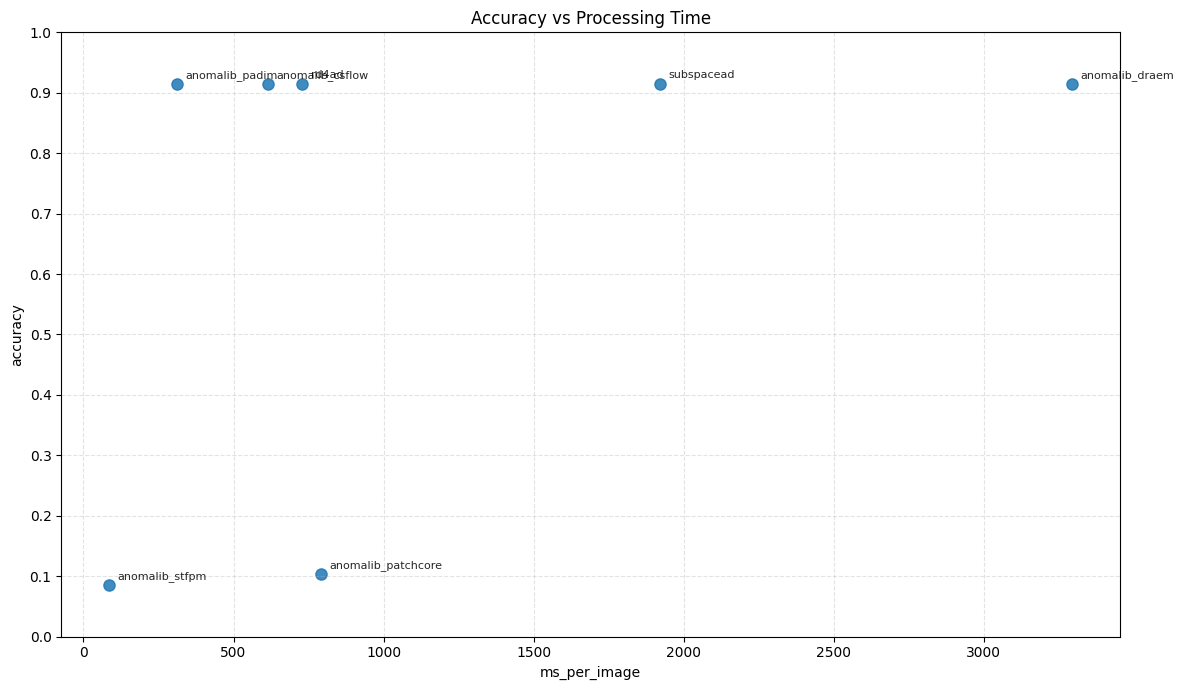

In [15]:
if HAS_WIDGETS:
    run_selector = widgets.SelectMultiple(
        options=all_runs,
        value=tuple(default_runs),
        description="Runs",
        rows=min(12, max(6, len(all_runs))),
        layout=widgets.Layout(width="520px"),
    )

    info = widgets.HTML(
        value=(
            f"<b>Detected runs:</b> {len(all_runs)} | "
            f"<b>Default:</b> all runs ({len(default_runs)})<br>"
            f"<b>Displayed metrics:</b> {', '.join(selected_metrics)}"
        )
    )

    output = widgets.Output()

    def refresh(_=None):
        with output:
            clear_output(wait=True)
            render_dashboard(
                df_all=df_all,
                selected_runs=list(run_selector.value),
                selected_metrics=selected_metrics,
            )

    run_selector.observe(refresh, names="value")

    controls = widgets.VBox([
        info,
        run_selector,
    ])

    display(controls, output)
    refresh()

else:
    print("ipywidgets is not installed. Manual mode enabled.")
    selected_runs = default_runs

    print("\nCurrent manual selection:")
    print("selected_runs =", selected_runs)
    print("selected_metrics =", selected_metrics)

    render_dashboard(
        df_all=df_all,
        selected_runs=selected_runs,
        selected_metrics=selected_metrics,
    )

